In [77]:
!unzip -o '/content/handsinfo.zip' -d '/content/dataset'
print("Dataset extracted successfully using unzip!")

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Hands/Hands/Hand_0006509.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006510.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006511.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006512.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006513.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006514.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006515.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006516.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006517.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006518.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006519.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006520.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006521.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006522.jpg  
  inflating: /content/dataset/Hands/Hands/Hand_0006523.jpg  
  inflating: /content/dataset/Hand

In [78]:
!ls -F /content/dataset

HandInfo.csv  Hands/


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image


In [ ]:
import pandas as pd

df = pd.read_csv('/content/dataset/HandInfo.csv')

df.head()

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              11076 non-null  int64 
 1   age             11076 non-null  int64 
 2   gender          11076 non-null  object
 3   skinColor       11076 non-null  object
 4   accessories     11076 non-null  int64 
 5   nailPolish      11076 non-null  int64 
 6   aspectOfHand    11076 non-null  object
 7   imageName       11076 non-null  object
 8   irregularities  11076 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 778.9+ KB


Total records: 11,076 hand images Total features: 9 columns Missing values: None (all columns have 11,076 non-null values)

In [82]:

df.isnull().sum()

,0
id,0
age,0
gender,0
skinColor,0
accessories,0
nailPolish,0
aspectOfHand,0
imageName,0
irregularities,0


In [83]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found, indicating that each image entry in the dataset is unique.

In [84]:
df["aspectOfHand"].value_counts()

,count
aspectOfHand,
dorsal right,2892
palmar right,2813
dorsal left,2788
palmar left,2583


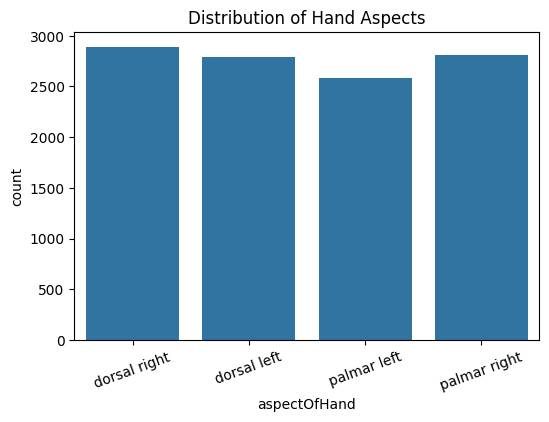

In [85]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="aspectOfHand")
plt.title("Distribution of Hand Aspects")
plt.xticks(rotation=20)
plt.show()

The distribution of hand aspects is nearly balanced across all four classes.

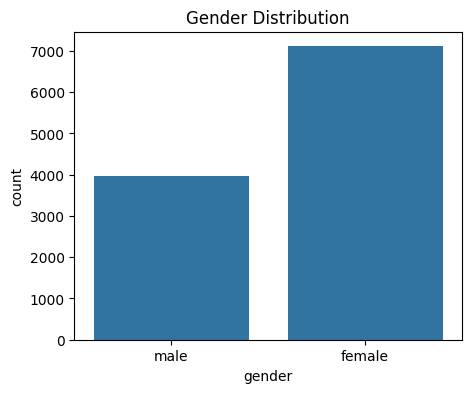

In [86]:

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.show()

The dataset contains more female hand images than male hand images

In [87]:
binary_cols = ["accessories", "nailPolish", "irregularities"]

for col in binary_cols:
    print("\n", col)
    print(df[col].value_counts())


 accessories
accessories
0    7865
1    3211
Name: count, dtype: int64

 nailPolish
nailPolish
0    10009
1     1067
Name: count, dtype: int64

 irregularities
irregularities
0    10912
1      164
Name: count, dtype: int64


In [88]:
import os
from PIL import Image

sample_image = os.path.join("/content/dataset/Hands/Hands", df.iloc[0]["imageName"])

img = Image.open(sample_image)

print("Image Size:", img.size)
print("Image Mode:", img.mode)


Image Size: (1600, 1200)
Image Mode: RGB


The dataset consists of high-resolution RGB images, which are suitable for computer vision tasks such as palm detection and palm line extraction.

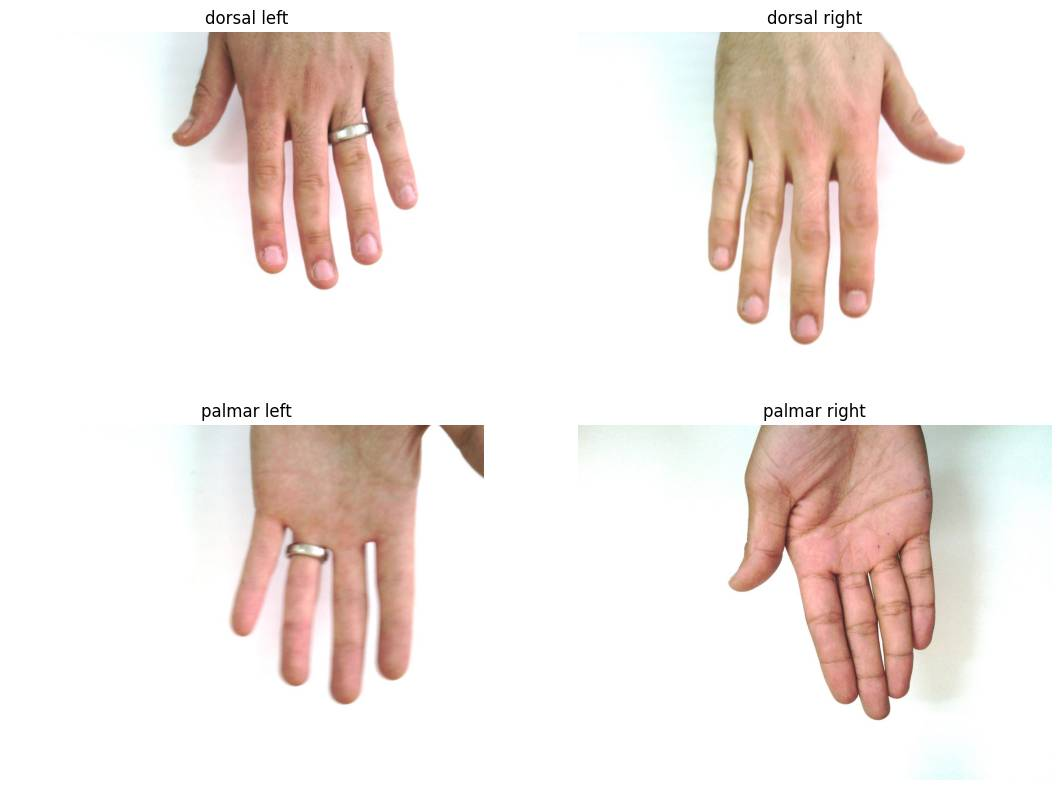

In [89]:
categories = ["dorsal left", "dorsal right", "palmar left", "palmar right"]

plt.figure(figsize=(12, 8))

for i, category in enumerate(categories):
    image_name = df[df["aspectOfHand"] == category].iloc[0]["imageName"]
    img = Image.open(f"/content/dataset/Hands/Hands/{image_name}")

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.tight_layout()
plt.show()




Since the objective of this project is palm line detection and palmistry analysis, only the palmar left and palmar right images will be used in the later stages.

In [90]:
palmar_df = df[df["aspectOfHand"].str.contains("palmar")]

print("Number of palmar images:", len(palmar_df))
palmar_df.head()

Number of palmar images: 5396


,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
30,0,27,male,fair,1,0,palmar left,Hand_0000038.jpg,0
31,0,27,male,fair,1,0,palmar left,Hand_0000039.jpg,0
32,0,27,male,fair,1,0,palmar left,Hand_0000040.jpg,0
33,0,27,male,fair,1,0,palmar left,Hand_0000041.jpg,0
34,0,27,male,fair,1,0,palmar left,Hand_0000042.jpg,0


Total images in dataset: 11,076
Total palmar images: 5,396

The remaining dorsal images are excluded from further processing.

In [91]:
palmar_df["aspectOfHand"].value_counts()

,count
aspectOfHand,
palmar right,2813
palmar left,2583


Key Findings

- The dataset contains 11,076 hand images with 9 metadata attributes.
No missing or duplicate records were found.
- Images are categorized into four classes: dorsal left, dorsal right, palmar left, and palmar right.
- The dataset contains 5,396 palmar images, which are relevant for the palmistry project.
(palmar right	2813)(palmar left	2583)

- Images have a resolution of 1600 × 1200 pixels and are in RGB format.

In [92]:
!pip -q install mediapipe

In [93]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [94]:
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task


In [95]:
base_options = python.BaseOptions(
    model_asset_path="hand_landmarker.task"
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2
)

detector = vision.HandLandmarker.create_from_options(options)

Selected Left Hand Image: /content/dataset/Hands/Hands/Hand_0000532.jpg
Selected Right Hand Image: /content/dataset/Hands/Hands/Hand_0000174.jpg
Created Combined Image: Combined: Hand_0000532.jpg & Hand_0000174.jpg


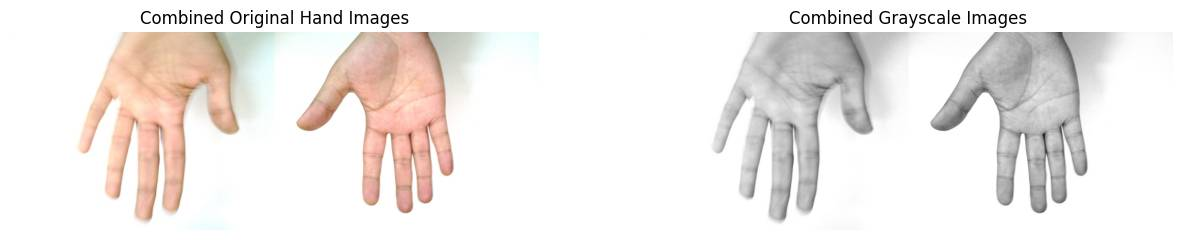

In [ ]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import random
import os
import numpy as np

# Base path for images
image_base_path = "/content/dataset/Hands/Hands"

# Filter palmar_df for left and right hands
palmar_left_images = palmar_df[palmar_df["aspectOfHand"] == "palmar left"]["imageName"].tolist()
palmar_right_images = palmar_df[palmar_df["aspectOfHand"] == "palmar right"]["imageName"].tolist()

# Randomly select one left and one right hand image name
selected_left_image_name = random.choice(palmar_left_images)
selected_right_image_name = random.choice(palmar_right_images)

# Construct full paths
left_image_path = os.path.join(image_base_path, selected_left_image_name)
right_image_path = os.path.join(image_base_path, selected_right_image_name)

print("Selected Left Hand Image:", left_image_path)
print("Selected Right Hand Image:", right_image_path)

# Read images
left_img = cv2.imread(left_image_path)
right_img = cv2.imread(right_image_path)


if left_img is None or right_img is None:
    raise FileNotFoundError("Could not load one or both selected hand images.")

# Resize images to have the same height for concatenation
h, w, _ = left_img.shape
right_img_resized = cv2.resize(right_img, (int(w * (h / right_img.shape[0])), h))

# Concatenate images horizontally to create a single 'two hands' image
img = np.hstack((left_img, right_img_resized))

# The image_path variable now represents a conceptual combined image
image_path = f"Combined: {selected_left_image_name} & {selected_right_image_name}"
print("Created Combined Image:", image_path)

# Convert BGR to RGB
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Assign to image and image_rgb for downstream cells
image = img
image_rgb = rgb

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15,7)) 

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("Combined Original Hand Images")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray,cmap="gray")
plt.title("Combined Grayscale Images")
plt.axis("off")

plt.show()

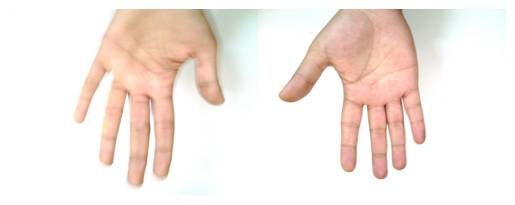

In [97]:
plt.imshow(image_rgb)

plt.axis("off")

plt.show()

In [98]:
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

result = detector.detect(mp_image)

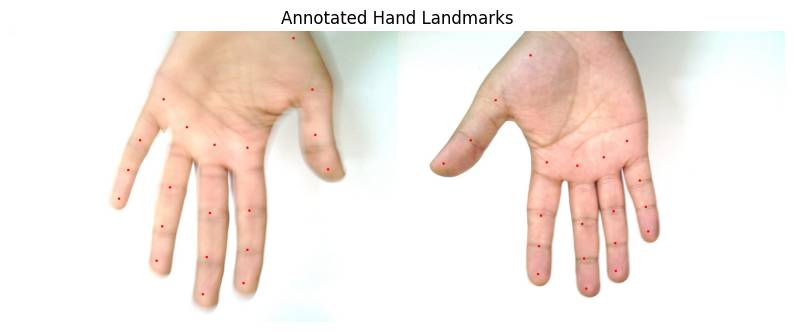

In [99]:
annotated = image_rgb.copy()

if result.hand_landmarks:
    h, w, _ = annotated.shape
    for hand_landmarks in result.hand_landmarks:
        for point in hand_landmarks:
            x = int(point.x * w)
            y = int(point.y * h)
            cv2.circle(
                annotated,
                (x, y),
                5,
                (255, 0, 0),
                -1
            )

plt.figure(figsize=(10, 8)) # Increased figure size for better visualization
plt.imshow(annotated)
plt.title("Annotated Hand Landmarks")
plt.axis("off")
plt.show()

In [100]:
if result.hand_landmarks:
    for i, hand_landmarks in enumerate(result.hand_landmarks):
        print(f"Number of Landmarks Detected for Hand {i+1}: {len(hand_landmarks)}")
else:
    print("No Hands Detected")

Number of Landmarks Detected for Hand 1: 21
Number of Landmarks Detected for Hand 2: 21


**Key Findings**

- Total Hands Detected: 2
- Total Landmarks on hand 1: 21
- Total Landmarks on hand 2: 21
- Detection Method: MediaPipe Hand Landmarker
- Input Image: RGB Palm Image
- Output: 21-21 Landmark Coordinates